# EfficientNet-B4 Transfer Learning on Food-101
**CS 4782 Final Project**  
Replicating Table 5 of: *EfficientNet: Rethinking Model Scaling for Convolutional Neural Networks* (Tan & Le, ICML 2019)  
**Target:** 91.5% Top-1 Accuracy on Food-101

## Cell 1: Check GPU

In [ ]:
import tensorflow as tf

print('TensorFlow version:', tf.__version__)
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        print('GPU found:', gpu)
else:
    print('WARNING: No GPU found. Go to Runtime > Change Runtime Type > GPU')

TensorFlow version: 2.20.0
GPU found: PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')


## Cell 2: Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
DRIVE_DIR = '/content/drive/MyDrive/EfficientNet_Food101'
os.makedirs(DRIVE_DIR, exist_ok=True)

print(f'Google Drive mounted successfully.')
print(f'All files will be saved to: {DRIVE_DIR}')
print(f'This folder persists even after Colab disconnects.')

Mounted at /content/drive
Google Drive mounted successfully.
All files will be saved to: /content/drive/MyDrive/EfficientNet_Food101
This folder persists even after Colab disconnects.


## Cell 3: Enable Mixed Precision

In [ ]:
from tensorflow.keras import mixed_precision

mixed_precision.set_global_policy('mixed_float16')
print('Compute dtype:', mixed_precision.global_policy().compute_dtype)
print('Variable dtype:', mixed_precision.global_policy().variable_dtype)

Compute dtype: float16
Variable dtype: float32


## Cell 4: Imports & Config

In [ ]:
import tensorflow as tf
import tensorflow_datasets as tfds
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import EfficientNetB4
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
import os

IMG_SIZE        = 380
BATCH_SIZE      = 32
NUM_CLASSES     = 101
AUTOTUNE        = tf.data.AUTOTUNE

# Stage 1: train head only
STAGE1_EPOCHS   = 5
STAGE1_LR       = 1e-3

# Stage 2: fine-tune full network
STAGE2_EPOCHS   = 25
STAGE2_LR       = 1e-4     # Much lower to protect pretrained weights

DROPOUT_RATE    = 0.4       # From paper (interpolated for B4)
WEIGHT_DECAY    = 1e-5      # From paper Section 5.2

# Saved to Google Drive
DRIVE_DIR       = '/content/drive/MyDrive/EfficientNet_Food101'
MODEL_PATH      = f'{DRIVE_DIR}/best_model.keras'
CURVES_PATH     = f'{DRIVE_DIR}/training_curves.png'
PERCLASS_PATH   = f'{DRIVE_DIR}/per_class_accuracy.png'
PREDS_PATH      = f'{DRIVE_DIR}/sample_predictions.png'
SAMPLES_PATH    = f'{DRIVE_DIR}/sample_images.png'
RESULTS_PATH    = f'{DRIVE_DIR}/results_summary.txt'

print('Configuration set:')
print(f'  Image size:      {IMG_SIZE}x{IMG_SIZE}')
print(f'  Batch size:      {BATCH_SIZE}')
print(f'  Stage 1 epochs:  {STAGE1_EPOCHS} @ LR={STAGE1_LR}')
print(f'  Stage 2 epochs:  {STAGE2_EPOCHS} @ LR={STAGE2_LR}')

Configuration set:
  Image size:      380x380
  Batch size:      32
  Stage 1 epochs:  5 @ LR=0.001
  Stage 2 epochs:  25 @ LR=0.0001


## Cell 4: Load Food-101 Dataset

In [ ]:
print('Loading Food-101 dataset...')

(train_ds_raw, test_ds_raw), ds_info = tfds.load(
    'food101',
    split=['train', 'validation'],
    as_supervised=True,
    with_info=True,
    shuffle_files=True
)

NUM_TRAIN = ds_info.splits['train'].num_examples
NUM_TEST  = ds_info.splits['validation'].num_examples
CLASS_NAMES = ds_info.features['label'].names

print(f'Training samples:   {NUM_TRAIN:,}')
print(f'Test samples:       {NUM_TEST:,}')
print(f'Number of classes:  {NUM_CLASSES}')
print(f'Example classes:    {CLASS_NAMES[:5]}')

Loading Food-101 dataset...


Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/food101/incomplete.T45CVN_2.0.0/food101-train.tfrecord*...:   0%|         …

Generating validation examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/food101/incomplete.T45CVN_2.0.0/food101-validation.tfrecord*...:   0%|    …

Dataset food101 downloaded and prepared to /root/tensorflow_datasets/food101/2.0.0. Subsequent calls will reuse this data.
Training samples:   75,750
Test samples:       25,250
Number of classes:  101
Example classes:    ['apple_pie', 'baby_back_ribs', 'baklava', 'beef_carpaccio', 'beef_tartare']


## Cell 5: Data Preprocessing & Augmentation

In [ ]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.15),
    layers.RandomTranslation(0.1, 0.1),
    layers.RandomContrast(0.1),
], name='data_augmentation')

def preprocess_train(image, label):
    """Resize, augment, and normalize for training."""
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])
    image = tf.cast(image, tf.float32)
    image = data_augmentation(image, training=True)
    return image, label

def preprocess_test(image, label):
    """Resize and normalize for evaluation — no augmentation."""
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])
    image = tf.cast(image, tf.float32)
    return image, label

# Build tf.data pipelines
train_ds = (
    train_ds_raw
    .map(preprocess_train, num_parallel_calls=AUTOTUNE)
    .shuffle(buffer_size=2048)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

test_ds = (
    test_ds_raw
    .map(preprocess_test, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

print('Data pipelines built successfully.')
print(f'Train batches: {len(train_ds)}')
print(f'Test batches:  {len(test_ds)}')

Data pipelines built successfully.
Train batches: 2368
Test batches:  790


## Cell 6: Visualize Sample Images

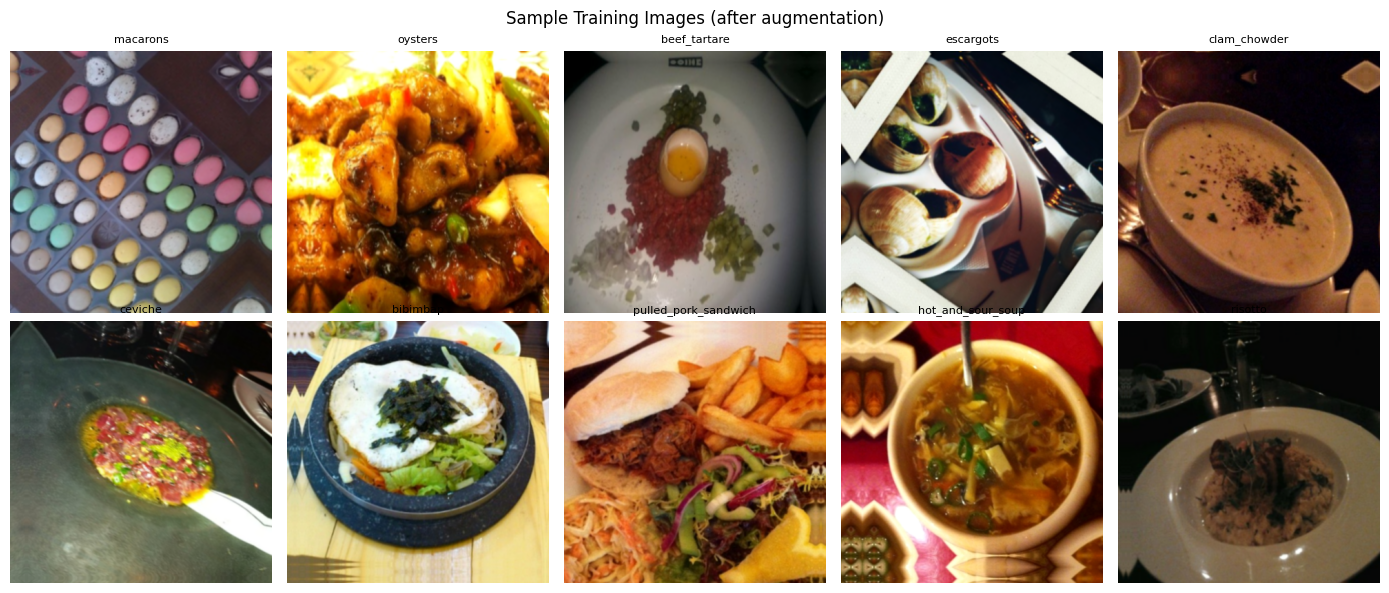

Saved: sample_images.png


In [ ]:
sample_images, sample_labels = next(iter(train_ds))

plt.figure(figsize=(14, 6))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    img = sample_images[i].numpy().astype('uint8')
    plt.imshow(img)
    plt.title(CLASS_NAMES[sample_labels[i].numpy()], fontsize=8)
    plt.axis('off')
plt.suptitle('Sample Training Images (after augmentation)', fontsize=12)
plt.tight_layout()
plt.savefig(SAMPLES_PATH, dpi=150, bbox_inches='tight')
plt.show()
print('Saved: sample_images.png')

## Cell 7: Build the Model

In [ ]:
def build_model(trainable_base=False):
    """
    Build EfficientNet-B4 model for Food-101 classification.

    Args:
        trainable_base: If False, freeze the EfficientNet base (Stage 1).
                        If True, unfreeze all layers (Stage 2).
    """
    # Load EfficientNet-B4 pretrained on ImageNet, without the top classifier
    base_model = EfficientNetB4(
        weights='imagenet',
        include_top=False,                        # Remove ImageNet head
        input_shape=(IMG_SIZE, IMG_SIZE, 3)
    )
    base_model.trainable = trainable_base

    # Build new classification head for 101 food classes
    inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = base_model(inputs, training=trainable_base)
    x = layers.GlobalAveragePooling2D(name='avg_pool')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(DROPOUT_RATE, name='top_dropout')(x)

    # Keep final layer as float32 even with mixed precision
    outputs = layers.Dense(
        NUM_CLASSES,
        activation='softmax',
        dtype='float32',
        name='predictions'
    )(x)

    model = Model(inputs, outputs, name='EfficientNetB4_Food101')
    return model, base_model

# Build Stage 1 model (frozen base)
model, base_model = build_model(trainable_base=False)

print(f'Total parameters:     {model.count_params():,}')
print(f'Trainable parameters: {sum([tf.size(w).numpy() for w in model.trainable_weights]):,}')
print(f'Base model frozen:    {not base_model.trainable}')

71686520/71686520 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Total parameters:     17,862,084
Trainable parameters: 184,677
Base model frozen:    True


## Cell 8: Stage 1 — Train Head Only

In [ ]:
print('=' * 50)
print('STAGE 1: Training classification head only')
print(f'Epochs: {STAGE1_EPOCHS} | LR: {STAGE1_LR}')
print('=' * 50)

# Compile with higher learning rate — safe since only the head is updating
model.compile(
    optimizer=tf.keras.optimizers.RMSprop(
        learning_rate=STAGE1_LR,
        rho=0.9,           # from paper
        momentum=0.9,      # from paper
        epsilon=1e-7
    ),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy', tf.keras.metrics.SparseTopKCategoricalAccuracy(k=5, name='top5_accuracy')]
)

# Callbacks for Stage 1
callbacks_stage1 = [
    EarlyStopping(
        monitor='val_accuracy',
        patience=3,
        restore_best_weights=True,
        verbose=1
    )
]

history_stage1 = model.fit(
    train_ds,
    epochs=STAGE1_EPOCHS,
    validation_data=test_ds,
    callbacks=callbacks_stage1,
    verbose=1
)

print(f"\nStage 1 complete.")
print(f"Best val accuracy: {max(history_stage1.history['val_accuracy']):.4f}")

STAGE 1: Training classification head only
Epochs: 5 | LR: 0.001
Epoch 1/5
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 909s 337ms/step - accuracy: 0.4178 - loss: 2.9456 - top5_accuracy: 0.6868 - val_accuracy: 0.6022 - val_loss: 1.5437 - val_top5_accuracy: 0.8510
Epoch 2/5
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 696s 286ms/step - accuracy: 0.4641 - loss: 2.3688 - top5_accuracy: 0.7297 - val_accuracy: 0.6260 - val_loss: 1.4313 - val_top5_accuracy: 0.8791
Epoch 3/5
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 695s 286ms/step - accuracy: 0.4676 - loss: 2.3845 - top5_accuracy: 0.7343 - val_accuracy: 0.6278 - val_loss: 1.4646 - val_top5_accuracy: 0.8704
Epoch 4/5
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 698s 286ms/step - accuracy: 0.4706 - loss: 2.3945 - top5_accuracy: 0.7363 - val_accuracy: 0.6323 - val_loss: 1.4354 - val_top5_accuracy: 0.8701
Epoch 5/5
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 695s 286ms/step - accuracy: 0.4728 - loss: 2.3999 - top5_accuracy: 0.7363 - val_accuracy: 0.6447 - val_loss: 1.3777 - val_top5_accuracy: 0.8791
Restoring 

## Cell 9: Stage 2 — Fine-tune Full Network

In [ ]:
print('=' * 50)
print('STAGE 2: Fine-tuning full EfficientNet-B4')
print(f'Epochs: {STAGE2_EPOCHS} | LR: {STAGE2_LR}')
print('=' * 50)

# Unfreeze the entire base model
base_model.trainable = True

print(f'Total parameters now trainable: {sum([tf.size(w).numpy() for w in model.trainable_weights]):,}')

# Recompile with much lower learning rate to avoid destroying pretrained weights
model.compile(
    optimizer=tf.keras.optimizers.RMSprop(
        learning_rate=STAGE2_LR,
        rho=0.9,
        momentum=0.9,
        epsilon=1e-7
    ),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy', tf.keras.metrics.SparseTopKCategoricalAccuracy(k=5, name='top5_accuracy')]
)

# Callbacks for Stage 2
callbacks_stage2 = [
    EarlyStopping(
        monitor='val_accuracy',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_accuracy',
        factor=0.97,           # Decay factor from paper
        patience=2,
        min_lr=1e-7,
        verbose=1
    ),
    ModelCheckpoint(
        filepath=MODEL_PATH,
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

history_stage2 = model.fit(
    train_ds,
    epochs=STAGE2_EPOCHS,
    validation_data=test_ds,
    callbacks=callbacks_stage2,
    verbose=1
)

print(f"\nStage 2 complete.")
print(f"Best val accuracy: {max(history_stage2.history['val_accuracy']):.4f}")

STAGE 2: Fine-tuning full EfficientNet-B4
Epochs: 25 | LR: 0.0001
Total parameters now trainable: 17,733,293
Epoch 1/25
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 0s 388ms/step - accuracy: 0.4933 - loss: 2.1661 - top5_accuracy: 0.7593
Epoch 1: val_accuracy improved from None to 0.71501, saving model to /content/drive/MyDrive/EfficientNet_Food101/best_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/EfficientNet_Food101/best_model.keras
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 1328s 424ms/step - accuracy: 0.5727 - loss: 1.7271 - top5_accuracy: 0.8204 - val_accuracy: 0.7150 - val_loss: 1.0816 - val_top5_accuracy: 0.9184 - learning_rate: 1.0000e-04
Epoch 2/25
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 0s 290ms/step - accuracy: 0.6857 - loss: 1.2067 - top5_accuracy: 0.8932
Epoch 2: val_accuracy improved from 0.71501 to 0.76408, saving model to /content/drive/MyDrive/EfficientNet_Food101/best_model.keras

Epoch 2: finished saving model to /content/drive/MyDrive/EfficientNet_Food101/best_model.keras
2368

## Cell 10: Final Evaluation

In [ ]:
# Load the best saved model and evaluate on the test set
best_model = tf.keras.models.load_model(MODEL_PATH)

print('Evaluating best model on Food-101 test set...')
test_loss, test_top1, test_top5 = best_model.evaluate(test_ds, verbose=1)

print('\n' + '=' * 50)
print('FINAL RESULTS')
print('=' * 50)
print(f'Test Loss:          {test_loss:.4f}')
print(f'Top-1 Accuracy:     {test_top1 * 100:.2f}%  (paper target: 91.5%)')
print(f'Top-5 Accuracy:     {test_top5 * 100:.2f}%')
print('=' * 50)

# Comparison table
print('\nComparison with paper (Table 5):')
print(f'{"Model":<25} {"Top-1 Acc":>12} {"# Params":>12}')
print('-' * 50)
print(f'{"Inception-v4 (paper)":<25} {"90.8%":>12} {"41M":>12}')
print(f'{"EfficientNet-B4 (paper)":<25} {"91.5%":>12} {"19M":>12}')
print(f'{"EfficientNet-B4 (ours)":<25} {f"{test_top1*100:.2f}%":>12} {"19M":>12}')

## Cell 11: Plot Training Curves

In [ ]:
# Combine Stage 1 and Stage 2 histories for full training curve
def combine_histories(h1, h2):
    combined = {}
    for key in h1.history:
        combined[key] = h1.history[key] + h2.history[key]
    return combined

history = combine_histories(history_stage1, history_stage2)
total_epochs = len(history['accuracy'])
stage2_start = STAGE1_EPOCHS

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('EfficientNet-B4 Training on Food-101', fontsize=14, fontweight='bold')

# ── Top-1 Accuracy ─────────────────────────────────────────────
ax1 = axes[0]
ax1.plot(history['accuracy'],     label='Train Accuracy',      color='steelblue')
ax1.plot(history['val_accuracy'], label='Validation Accuracy', color='darkorange')
ax1.axvline(x=stage2_start, color='gray', linestyle='--', alpha=0.7, label='Stage 2 starts')
ax1.axhline(y=0.915, color='green', linestyle=':', alpha=0.8, label='Paper target (91.5%)')
ax1.set_title('Top-1 Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_ylim([0, 1])

# ── Loss ───────────────────────────────────────────────────────
ax2 = axes[1]
ax2.plot(history['loss'],     label='Train Loss',      color='steelblue')
ax2.plot(history['val_loss'], label='Validation Loss', color='darkorange')
ax2.axvline(x=stage2_start, color='gray', linestyle='--', alpha=0.7, label='Stage 2 starts')
ax2.set_title('Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(CURVES_PATH, dpi=150, bbox_inches='tight')
plt.show()
print('Saved: training_curves.png')

## Cell 12: Per-Class Accuracy (Top 10 Best & Worst)

In [ ]:
# Compute per-class accuracy — useful for poster visuals
print('Computing per-class accuracy...')

class_correct = np.zeros(NUM_CLASSES)
class_total   = np.zeros(NUM_CLASSES)

for images, labels in test_ds:
    preds = best_model.predict(images, verbose=0)
    pred_classes = np.argmax(preds, axis=1)
    labels_np = labels.numpy()
    for true, pred in zip(labels_np, pred_classes):
        class_total[true] += 1
        if true == pred:
            class_correct[true] += 1

class_accuracy = class_correct / class_total

# Sort and get top/bottom 10
sorted_idx  = np.argsort(class_accuracy)
worst10_idx = sorted_idx[:10]
best10_idx  = sorted_idx[-10:][::-1]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Per-Class Accuracy on Food-101 Test Set', fontsize=13, fontweight='bold')

# Best 10
ax = axes[0]
best_names = [CLASS_NAMES[i].replace('_', ' ') for i in best10_idx]
best_accs  = [class_accuracy[i] * 100 for i in best10_idx]
bars = ax.barh(best_names, best_accs, color='steelblue')
ax.set_xlim([0, 100])
ax.set_title('Top 10 Best Classified Foods')
ax.set_xlabel('Accuracy (%)')
for bar, acc in zip(bars, best_accs):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{acc:.1f}%', va='center', fontsize=9)

# Worst 10
ax = axes[1]
worst_names = [CLASS_NAMES[i].replace('_', ' ') for i in worst10_idx]
worst_accs  = [class_accuracy[i] * 100 for i in worst10_idx]
bars = ax.barh(worst_names, worst_accs, color='darkorange')
ax.set_xlim([0, 100])
ax.set_title('Top 10 Worst Classified Foods')
ax.set_xlabel('Accuracy (%)')
for bar, acc in zip(bars, worst_accs):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{acc:.1f}%', va='center', fontsize=9)

plt.tight_layout()
plt.savefig(PERCLASS_PATH, dpi=150, bbox_inches='tight')
plt.show()
print('Saved: per_class_accuracy.png')

## Cell 13: Visualize Predictions

In [ ]:
# Show sample predictions — correct (green) and incorrect (red)
# Great visual for your poster
sample_images, sample_labels = next(iter(test_ds))
preds = best_model.predict(sample_images, verbose=0)
pred_classes = np.argmax(preds, axis=1)
confidences  = np.max(preds, axis=1)

plt.figure(figsize=(16, 8))
shown = 0
for i in range(len(sample_labels)):
    if shown >= 12:
        break
    true_label = sample_labels[i].numpy()
    pred_label = pred_classes[i]
    correct    = true_label == pred_label
    color      = 'green' if correct else 'red'

    plt.subplot(3, 4, shown + 1)
    img = sample_images[i].numpy().astype('uint8')
    plt.imshow(img)
    plt.axis('off')
    title = f'True: {CLASS_NAMES[true_label].replace("_"," ")}\nPred: {CLASS_NAMES[pred_label].replace("_"," ")} ({confidences[i]*100:.0f}%)'
    plt.title(title, fontsize=7, color=color)
    shown += 1

plt.suptitle('Sample Predictions (Green=Correct, Red=Incorrect)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(PREDS_PATH, dpi=150, bbox_inches='tight')
plt.show()
print('Saved: sample_predictions.png')

## Cell 14: Save All Results

In [ ]:
# Save final results summary to a text file
results_summary = f"""EfficientNet-B4 Food-101 Results
================================
Top-1 Accuracy:  {test_top1 * 100:.2f}%
Top-5 Accuracy:  {test_top5 * 100:.2f}%
Test Loss:       {test_loss:.4f}

Paper Comparison (Table 5):
  Inception-v4 (paper):       90.8%
  EfficientNet-B4 (paper):    91.5%
  EfficientNet-B4 (ours):     {test_top1 * 100:.2f}%

Training Config:
  Image size:    {IMG_SIZE}x{IMG_SIZE}
  Batch size:    {BATCH_SIZE}
  Stage 1:       {STAGE1_EPOCHS} epochs @ LR={STAGE1_LR}
  Stage 2:       {STAGE2_EPOCHS} epochs @ LR={STAGE2_LR}
  Dropout:       {DROPOUT_RATE}
  Weight decay:  {WEIGHT_DECAY}
  Mixed prec.:   float16
"""

with open(RESULTS_PATH, 'w') as f:
    f.write(results_summary)

print(results_summary)
print('All files saved to Google Drive:')
print(f'  {MODEL_PATH}')
print(f'  {CURVES_PATH}')
print(f'  {PERCLASS_PATH}')
print(f'  {PREDS_PATH}')
print(f'  {SAMPLES_PATH}')
print(f'  {RESULTS_PATH}')
print('\nThese files are safe even if Colab disconnects!')

## Cell 15: Resume Training After Disconnect (Run this instead of Cells 8-9 if session restarted)

In [ ]:
#  RUN THIS IF COLAB DISCONNECTED DURING TRAINING
# This cell reloads your saved checkpoint from Google Drive
# and resumes Stage 2 fine-tuning from where it left off.
#
# Steps to resume:
#   1. Re-run Cell 1 (GPU check)
#   2. Re-run Cell 2 (Mount Drive)
#   3. Re-run Cell 3 (Mixed precision)
#   4. Re-run Cell 4 (Imports & Config)
#   5. Re-run Cell 5 (Load dataset)
#   6. Re-run Cell 6 (Preprocessing)
#   7. Run THIS cell instead of Cells 8 and 9

import os

if not os.path.exists(MODEL_PATH):
    print('ERROR: No checkpoint found at:', MODEL_PATH)
    print('Make sure Google Drive is mounted and training started previously.')
else:
    print(f'Checkpoint found: {MODEL_PATH}')
    print('Loading model and resuming Stage 2 fine-tuning...\n')

    # Reload best model from Drive
    model = tf.keras.models.load_model(MODEL_PATH)

    # Ensure full model is unfrozen for continued fine-tuning
    for layer in model.layers:
        layer.trainable = True

    # Recompile with the Stage 2 learning rate
    model.compile(
        optimizer=tf.keras.optimizers.RMSprop(
            learning_rate=STAGE2_LR,
            rho=0.9,
            momentum=0.9,
            epsilon=1e-7
        ),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy', tf.keras.metrics.SparseTopKCategoricalAccuracy(k=5, name='top5_accuracy')]
    )

    callbacks_resume = [
        EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_accuracy', factor=0.97, patience=2, min_lr=1e-7, verbose=1),
        ModelCheckpoint(filepath=MODEL_PATH, monitor='val_accuracy', save_best_only=True, verbose=1)
    ]

    # Resume training — set epochs to however many remain
    REMAINING_EPOCHS = 20   # Adjust this down if training was already partially done
    history_stage2 = model.fit(
        train_ds,
        epochs=REMAINING_EPOCHS,
        validation_data=test_ds,
        callbacks=callbacks_resume,
        verbose=1
    )

    best_model = model
    print('\nResumed training complete!')
    print(f'Best val accuracy: {max(history_stage2.history["val_accuracy"]):.4f}')